In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definindo os parâmetros do modelo
beta0 = 0.0
beta1 = 0.01  # Coeficiente para iluminação
beta2 = 0.02  # Coeficiente para qualidade da imagem
beta3 = 0.01  # Coeficiente para ISO
beta4 = 0.03  # Coeficiente para abertura

# Definindo os intervalos de iluminação, qualidade da imagem, ISO e abertura
iluminacao_min = 0
iluminacao_max = 700
qualidade_min = 0.1
qualidade_max = 0.9
iso_min = 100
iso_max = 400
abertura_min = 0.5
abertura_max = 16.0

# Criando um DataFrame para armazenar os resultados
resultados_df = pd.DataFrame(columns=['Iluminacao', 'Qualidade_Imagem', 'ISO', 'Abertura', 'Taxa_Efetividade'])

# Função logística
def funcao_logistica(z):
    return 1 / (1 + np.exp(-z))

# Número de simulações de Monte Carlo
num_simulacoes = 10000  # Pode ajustar conforme necessário

# Realizando simulações de Monte Carlo
for _ in range(num_simulacoes):
    # Gerando valores aleatórios para iluminação, qualidade da imagem, ISO e abertura
    ilum = np.random.uniform(iluminacao_min, iluminacao_max)
    qual = np.random.uniform(qualidade_min, qualidade_max)
    iso = np.random.uniform(iso_min, iso_max)
    abertura = np.random.uniform(abertura_min, abertura_max)

    z = (beta0 + beta1 * ilum + beta2 * qual + beta3 * iso + beta4 * abertura)
    taxa_efetividade = funcao_logistica(z)

    # Armazenando os resultados
    resultados_df = pd.concat([resultados_df, pd.DataFrame({
        'Iluminacao': [ilum],
        'Qualidade_Imagem': [qual],
        'ISO': [iso],
        'Abertura': [abertura],
        'Taxa_Efetividade': [taxa_efetividade]
    })], ignore_index=True)

# Visualizando os resultados em um histograma
plt.figure(figsize=(10, 6))
plt.hist(iluminacao_simulada, bins=20, weights=taxa_reconhecimento_ajustada, color='skyblue', edgecolor='black')
plt.xlabel('Taxa de Efetividade do Reconhecimento Facial')
plt.ylabel('Iluminação')
plt.title('Distribuição da Taxa de Efetividade ')
plt.grid()
plt.show()

# Exibindo os resultados da tabela
print(resultados_df)

# Contando reconhecimentos
reconhecidos = resultados_df[resultados_df['Taxa_Efetividade'] > 0.99].shape[0]
nao_reconhecidos = resultados_df[resultados_df['Taxa_Efetividade'] <= 0.99].shape[0]

# Exibindo a quantidade de taxas de reconhecimento positivas e negativas
print(f"Quantidade de reconhecimentos positivos: {reconhecidos}")
print(f"Quantidade de reconhecimentos negativos: {nao_reconhecidos}")

<ipython-input-1-f42b529169a6>:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultados_df = pd.concat([resultados_df, pd.DataFrame({


NameError: name 'iluminacao_simulada' is not defined

<Figure size 1000x600 with 0 Axes>

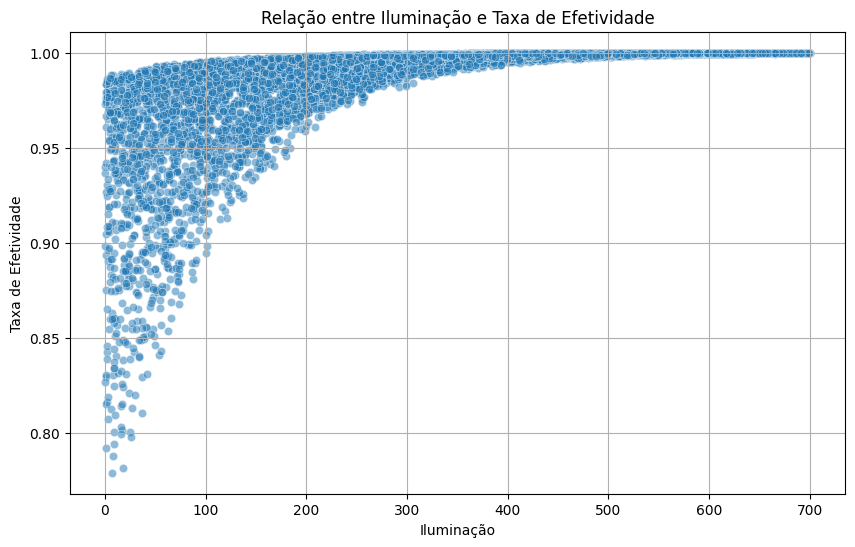

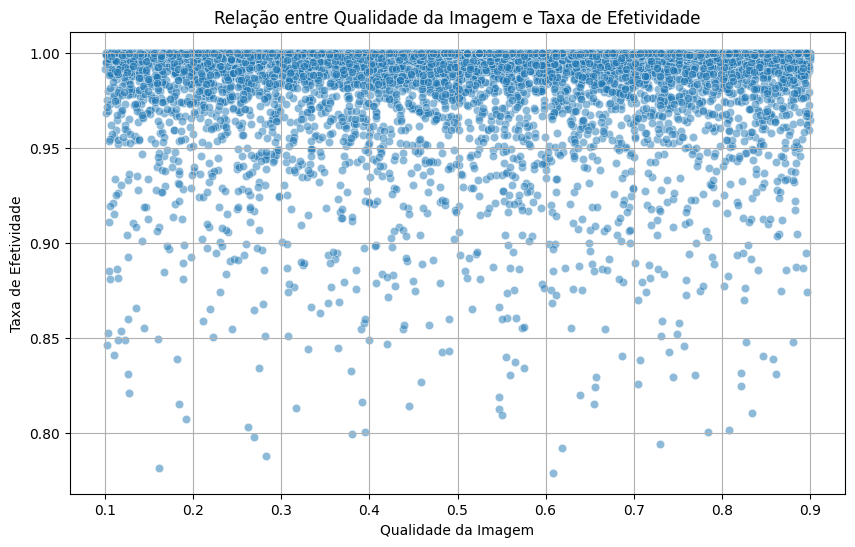

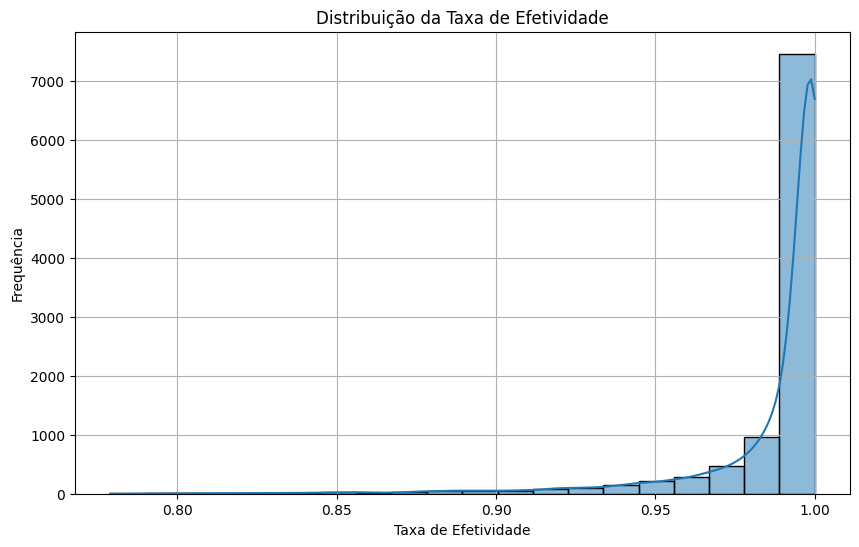

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de dispersão (scatter plot) para visualizar a relação entre iluminação e taxa de efetividade
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Iluminacao', y='Taxa_Efetividade', data=resultados_df, alpha=0.5)
plt.xlabel('Iluminação')
plt.ylabel('Taxa de Efetividade')
plt.title('Relação entre Iluminação e Taxa de Efetividade')
plt.grid(True)
plt.show()

# Gráfico de dispersão (scatter plot) para visualizar a relação entre qualidade da imagem e taxa de efetividade
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Qualidade_Imagem', y='Taxa_Efetividade', data=resultados_df, alpha=0.5)
plt.xlabel('Qualidade da Imagem')
plt.ylabel('Taxa de Efetividade')
plt.title('Relação entre Qualidade da Imagem e Taxa de Efetividade')
plt.grid(True)
plt.show()


# Histograma para visualizar a distribuição da taxa de efetividade
plt.figure(figsize=(10, 6))
sns.histplot(resultados_df['Taxa_Efetividade'], bins=20, kde=True)
plt.xlabel('Taxa de Efetividade')
plt.ylabel('Frequência')
plt.title('Distribuição da Taxa de Efetividade')
plt.grid(True)
plt.show()

# Gráfico de caixa (box plot) para visualizar a distribuição da taxa de efetividade para diferentes níveis de iluminação (ou outros parâmetros)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Iluminacao', y='Taxa_Efetividade', data=resultados_df)
plt.xlabel('Iluminação')
plt.ylabel('Taxa de Efetividade')
plt.title('Distribuição da Taxa de Efetividade para Diferentes Níveis de Iluminação')
plt.grid(True)
plt.show()



<ipython-input-2-ae40d6905220>:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultados_df = pd.concat([resultados_df, pd.DataFrame({


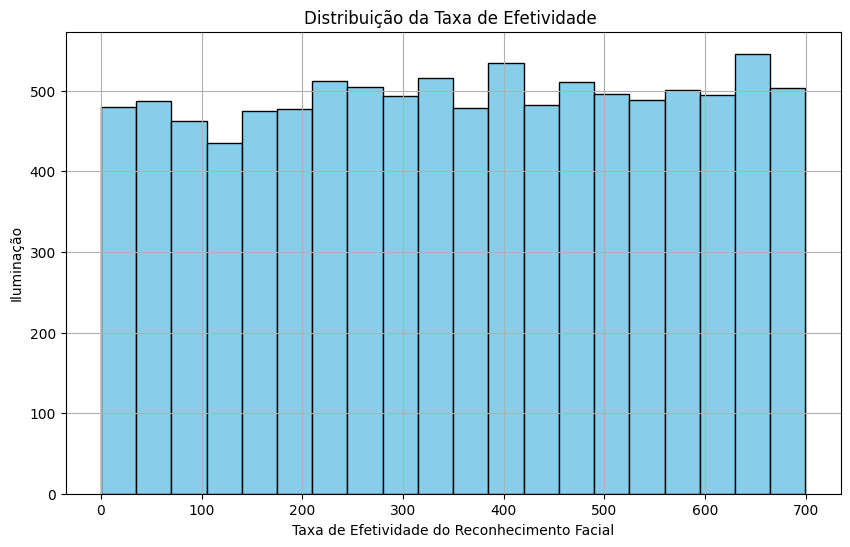

      Iluminacao  Qualidade_Imagem         ISO   Abertura  Taxa_Efetividade
0     372.269370          0.753045  311.300197   6.106284          0.999119
1     460.503934          0.258699  238.127508   4.900090          0.999207
2      71.983202          0.404927  160.152372  12.056828          0.936503
3     455.924769          0.109330  370.625385   6.064753          0.999786
4     602.931183          0.772720  129.181292   5.893856          0.999455
...          ...               ...         ...        ...               ...
9995  628.142680          0.196990  316.237867   7.783452          0.999938
9996  560.679001          0.595175  199.279096   6.008454          0.999587
9997  693.016546          0.588267  396.108913   2.949815          0.999983
9998  491.185487          0.361925  312.114662   4.128518          0.999715
9999  100.577836          0.583483  138.212600  12.186226          0.940764

[10000 rows x 5 columns]
Quantidade de reconhecimentos positivos: 7445
Quantidade de re

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definindo os parâmetros do modelo
beta0 = 0.0
beta1 = 0.01  # Coeficiente para iluminação
beta2 = 0.02  # Coeficiente para qualidade da imagem
beta3 = 0.01  # Coeficiente para ISO
beta4 = 0.03  # Coeficiente para abertura

# Definindo os intervalos de iluminação, qualidade da imagem, ISO e abertura
iluminacao_min = 0
iluminacao_max = 700
qualidade_min = 0.1
qualidade_max = 0.9
iso_min = 100
iso_max = 400
abertura_min = 0.5
abertura_max = 16.0

# Criando um DataFrame para armazenar os resultados
resultados_df = pd.DataFrame(columns=['Iluminacao', 'Qualidade_Imagem', 'ISO', 'Abertura', 'Taxa_Efetividade'])

# Função logística
def funcao_logistica(z):
    return 1 / (1 + np.exp(-z))

# Número de simulações de Monte Carlo
num_simulacoes = 10000  # Pode ajustar conforme necessário

# Realizando simulações de Monte Carlo
for _ in range(num_simulacoes):
    # Gerando valores aleatórios para iluminação, qualidade da imagem, ISO e abertura
    ilum = np.random.uniform(iluminacao_min, iluminacao_max)
    qual = np.random.uniform(qualidade_min, qualidade_max)
    iso = np.random.uniform(iso_min, iso_max)
    abertura = np.random.uniform(abertura_min, abertura_max)

    z = (beta0 + beta1 * ilum + beta2 * qual + beta3 * iso + beta4 * abertura)
    taxa_efetividade = funcao_logistica(z)

    # Armazenando os resultados
    resultados_df = pd.concat([resultados_df, pd.DataFrame({
        'Iluminacao': [ilum],
        'Qualidade_Imagem': [qual],
        'ISO': [iso],
        'Abertura': [abertura],
        'Taxa_Efetividade': [taxa_efetividade]
    })], ignore_index=True)

# Visualizando os resultados em um histograma
plt.figure(figsize=(10, 6))
# Use 'Iluminacao' values from the DataFrame
plt.hist(resultados_df['Iluminacao'], bins=20, weights=resultados_df['Taxa_Efetividade'], color='skyblue', edgecolor='black')
plt.xlabel('Taxa de Efetividade do Reconhecimento Facial')
plt.ylabel('Iluminação')
plt.title('Distribuição da Taxa de Efetividade ')
plt.grid()
plt.show()

# Exibindo os resultados da tabela
print(resultados_df)

# Contando reconhecimentos
reconhecidos = resultados_df[resultados_df['Taxa_Efetividade'] > 0.99].shape[0]
nao_reconhecidos = resultados_df[resultados_df['Taxa_Efetividade'] <= 0.99].shape[0]

# Exibindo a quantidade de taxas de reconhecimento positivas e negativas
print(f"Quantidade de reconhecimentos positivos: {reconhecidos}")
print(f"Quantidade de reconhecimentos negativos: {nao_reconhecidos}")

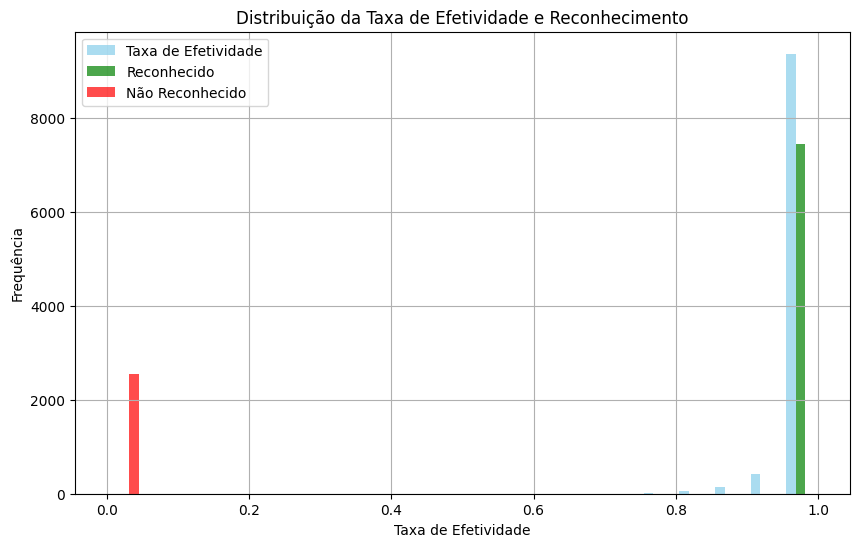

In [ ]:
# prompt: como eu poderia plotar um histograma usando as nariaveis reconhecido e nao reconhecido e plotar tamten junto as taxa de reconhecimento

import matplotlib.pyplot as plt

# Dados para o histograma
reconhecidos_count = reconhecidos
nao_reconhecidos_count = nao_reconhecidos
taxas_reconhecimento = resultados_df['Taxa_Efetividade']

# Criando o histograma
plt.figure(figsize=(10, 6))
plt.hist([taxas_reconhecimento, [1] * reconhecidos_count, [0] * nao_reconhecidos_count],
         bins=20,
         label=['Taxa de Efetividade', 'Reconhecido', 'Não Reconhecido'],
         color=['skyblue', 'green', 'red'],
         alpha=0.7)

# Configurando o gráfico
plt.xlabel('Taxa de Efetividade')
plt.ylabel('Frequência')
plt.title('Distribuição da Taxa de Efetividade e Reconhecimento')
plt.legend()
plt.grid(True)
plt.show()
